In [1]:
import pandas as pd
import numpy as np

# 1. Create the messy data dictionary
data = {
    'Employee_ID': [101, 102, 103, 104, 105, 106, 102, 108, 109, 110], # Duplicate ID involved
    'Years_Experience': [1.1, 1.3, 3.0, np.nan, 2.2, 5.5, 1.3, 7.9, 10.5, 3.0], # Missing value (NaN)
    'Age': [21, 22, 25, 24, 23, -5, 22, 30, 35, 25], # Dirty data: Age cannot be -5
    'Current_Salary': [39343, 46205, 60150, 42000, 39891, 66029, 46205, 101302, 121872, 60150] # Target Variable
}

# 2. Load into a DataFrame
df = pd.DataFrame(data)

# Display the raw messy data
print("--- Raw Messy Data ---")
print(df)

--- Raw Messy Data ---
   Employee_ID  Years_Experience  Age  Current_Salary
0          101               1.1   21           39343
1          102               1.3   22           46205
2          103               3.0   25           60150
3          104               NaN   24           42000
4          105               2.2   23           39891
5          106               5.5   -5           66029
6          102               1.3   22           46205
7          108               7.9   30          101302
8          109              10.5   35          121872
9          110               3.0   25           60150


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Employee_ID       10 non-null     int64  
 1   Years_Experience  9 non-null      float64
 2   Age               10 non-null     int64  
 3   Current_Salary    10 non-null     int64  
dtypes: float64(1), int64(3)
memory usage: 452.0 bytes


In [4]:
df.isnull().sum()

Employee_ID         0
Years_Experience    1
Age                 0
Current_Salary      0
dtype: int64

In [5]:
df.duplicated()

0    False
1    False
2    False
3    False
4    False
5    False
6     True
7    False
8    False
9    False
dtype: bool

In [6]:
df.drop_duplicates()

,Employee_ID,Years_Experience,Age,Current_Salary
0,101,1.1,21,39343
1,102,1.3,22,46205
2,103,3.0,25,60150
3,104,NaN,24,42000
4,105,2.2,23,39891
5,106,5.5,-5,66029
7,108,7.9,30,101302
8,109,10.5,35,121872
9,110,3.0,25,60150


In [8]:
df['Years_Experience']=df['Years_Experience'].fillna(df['Years_Experience'].sum())

In [9]:
X = df[['Years_Experience']]
y = df['Current_Salary']

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Split data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and Train
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

print("\n--- Predictions ---")
print(predictions)


--- Predictions ---
[56304.16811292 58066.86343891]


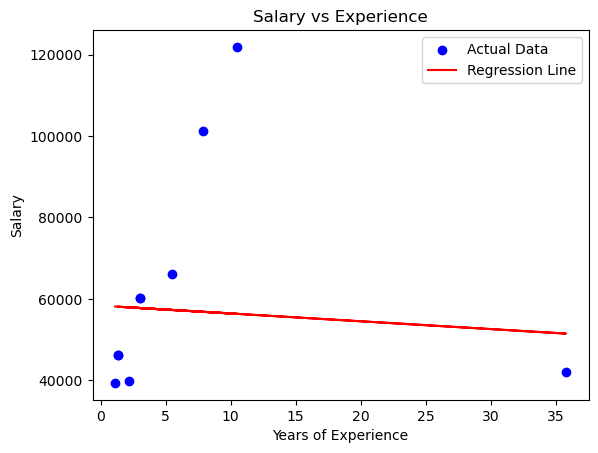

In [11]:
import matplotlib.pyplot as plt

# 1. Plot the real data points (scatter plot)
plt.scatter(X, y, color='blue', label='Actual Data')

# 2. Plot the regression line (the AI's prediction line)
# We use the model to predict for the whole X dataset to draw the full line
plt.plot(X, model.predict(X), color='red', label='Regression Line')

plt.title('Salary vs Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate the metrics
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions) # Squared error (hard to read)
rmse = np.sqrt(mse) # Root Mean Squared (easier to read, in $)
r2 = r2_score(y_test, predictions)

print("--- Model Report Card ---")
print(f"MAE (Average Error):      ${mae:.2f}")
print(f"RMSE (Standard Error):    ${rmse:.2f}")
print(f"R-Squared (Accuracy):     {r2:.4f}")

--- Model Report Card ---
MAE (Average Error):      $38714.85
RMSE (Standard Error):    $47116.05
R-Squared (Accuracy):     -0.5509


In [13]:
# 1. Generate BETTER Data (100 Employees, linear pattern)
# We add a little random "noise" so it's not a perfect straight line (realistic)
X_new = np.arange(1, 101).reshape(-1, 1) * 0.1  # Experience: 0.1 to 10.0 years
y_noise = np.random.normal(0, 5000, 100)        # Random variation of +/- $5000
y_new = 30000 + (X_new.flatten() * 8000) + y_noise # Base $30k + $8k/year

# 2. Split (80 Train / 20 Test)
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

# 3. Train
model_new = LinearRegression()
model_new.fit(X_train_new, y_train_new)

# 4. Predict & Evaluate
preds_new = model_new.predict(X_test_new)
r2_new = r2_score(y_test_new, preds_new)

print("--- New Model Report Card ---")
print(f"Old Accuracy: {r2:.4f}")
print(f"New Accuracy: {r2_new:.4f} (Closer to 1.0 is better)")

--- New Model Report Card ---
Old Accuracy: -0.5509
New Accuracy: 0.9596 (Closer to 1.0 is better)


Predicted price for 1100 sq.ft house: 55.0 Lakhs
Equation: Price = 0.05 * Size + 0.00


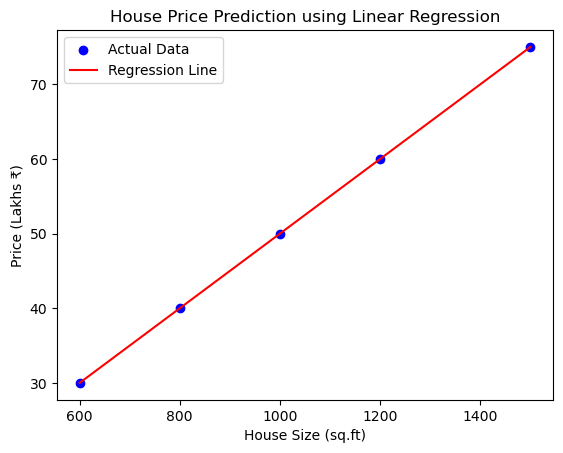

In [14]:
# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Step 2: Dataset (Size vs Price)
size = np.array([600, 800, 1000, 1200, 1500]).reshape(-1, 1)
price = np.array([30, 40, 50, 60, 75])

# Step 3: Create Model
model = LinearRegression()

# Step 4: Train Model
model.fit(size, price)

# Step 5: Predict new house price
new_size = np.array([[1100]])
predicted_price = model.predict(new_size)

print("Predicted price for 1100 sq.ft house:", predicted_price[0], "Lakhs")

# Step 6: Model Equation
m = model.coef_[0]
c = model.intercept_
print(f"Equation: Price = {m:.2f} * Size + {c:.2f}")

# Step 7: Plot Graph
plt.scatter(size, price, color='blue', label="Actual Data")
plt.plot(size, model.predict(size), color='red', label="Regression Line")
plt.xlabel("House Size (sq.ft)")
plt.ylabel("Price (Lakhs ₹)")
plt.title("House Price Prediction using Linear Regression")
plt.legend()
plt.show()
